# 🔥 4-1 수업용 실습 문제

### 문제 1

시그모이드 함수 그래프를 직접 그려보시오.

z = -10부터 10까지를 균등하게 나눈 값 200개를 생성, np.linespace(-10,10,200)

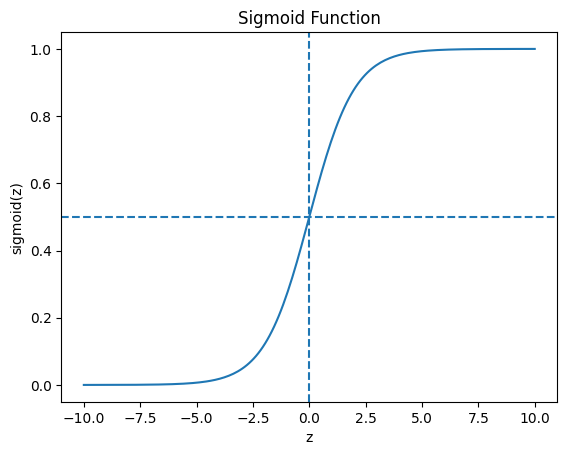

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# z 범위
z = np.linspace(-10, 10, 200)

# sigmoid
sigmoid = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sigmoid)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.show()

### 해설

- z가 **크게 음수**면 확률이 **0에 가까워지고**
- z가 **크게 양수**면 확률이 **1에 가까워져요**
- z=0일 때 sigmoid=0.5 (기준점)

### 문제 2

fish.csv데이터를 로드하여  fish_input과 fish_target로 나뉘어 담고 

훈련과 데스트 세트로 분리한 후 표준화 한다.

로지스틱 회귀로 다중 분류 수행한다.

C 값을 0.1, 1, 10 으로 바꿔 정확도를 비교하시오.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#데이터 로드
fish = pd.read_csv('./data/fish.csv')

fish_input = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

#훈련세트 만들기
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

#표준화
ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled  = ss.transform(test_input)

In [10]:
C_list = [0.1, 1, 10]

for C in C_list:
    lr = LogisticRegression(C=C, max_iter=1000)
    lr.fit(train_scaled, train_target)

    train_pred = lr.predict(train_scaled)
    test_pred  = lr.predict(test_scaled)

    train_score = lr.score(train_scaled, train_target)

    train_acc = accuracy_score(train_target, train_pred)
    test_acc  = accuracy_score(test_target, test_pred)

    print(f"C={C:<4} | train acc={train_acc:.4f}| train_score={train_score:.4f} | test acc={test_acc:.4f}")

    # < 왼쪽정렬, 4 - 최소 4칸 사용
    # > 오른쪽 정렬,  ^ 가운데 정렬


C=0.1  | train acc=0.7059| train_score=0.7059 | test acc=0.7750
C=1    | train acc=0.8067| train_score=0.8067 | test acc=0.8500
C=10   | train acc=0.9160| train_score=0.9160 | test acc=0.9250


In [ ]:
# LogisticRegression.score → Accuracy
# KNeighborsClassifier.score → Accuracy

# LinearRegression.score → R²
# KNeighborsRegressor.score → R²

### 문제 3

이진 분류 데이터 만들기(도미 vs 빙어)

- 데이터 로드 ⇒ 도미. 빙어만 선택 ⇒ 훈련세트 나누기 ⇒ 표준화 ⇒ 로지스틱 회귀 학습

coef_ 값을 보고 어떤 특성이 가장 중요한지 설명하시오.

---

In [15]:
# 이진 분류 데이터 만들기 (도미 vs 빙어)

# 데이터 로드
fish = pd.read_csv('./data/fish.csv')

fish_input = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

# 도미 & 빙어만 선택
mask = (fish_target == 'Bream') | (fish_target == 'Smelt')
fish_input = fish_input[mask]
fish_target = fish_target[mask]

# train/test split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

# 표준화
ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled  = ss.transform(test_input)

In [ ]:
# 2️⃣ 로지스틱 회귀 학습

lr = LogisticRegression()
lr.fit(train_scaled, train_target)

print("coef_ :", lr.coef_)
print("intercept_ :", lr.intercept_)

# ['Weight','Length','Diagonal','Height','Width']
# 스케일이 같으니 "가중치 절댓값이 큰 특성 = 영향이 큼"으로 해석 가능

coef_ : [[-0.57717269 -0.79233938 -0.82533982 -0.86579233 -0.82205625]]
intercept_ : [-2.38186126]


In [18]:
lr.classes_

array(['Bream', 'Smelt'], dtype=object)

In [ ]:
# 최종 해석
# Height의 계수가 가장 크므로 가장 중요한 특성이다.
# 계수가 음수이므로 Height 값이 증가할수록 Smelt 확률은 감소하고 Bream 확률은 증가한다.
# 즉, 키가 클수록 도미일 가능성이 높아진다.